# 🧠 Brain Tumor MRI — All Models Comparison

**Dataset:** [Brain Tumor MRI — masoudnickparvar (Kaggle)](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)  
**Task:** 4-class MRI classification — glioma · meningioma · notumor · pituitary

---

| # | Model | Reference | Framework |
|---|-------|-----------|----------|
| 1 | **Custom CNN** | [Kaggle — yousefmohamed20](https://www.kaggle.com/code/yousefmohamed20/brain-tumor-mri-accuracy-99) | TensorFlow/Keras |
| 2 | **VGG16** | [GitHub — 611noorsaeed](https://github.com/611noorsaeed/Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision) | TensorFlow/Keras |
| 3 | **MobileNetV3Large** | [GitHub — HosseinJafari2001](https://github.com/HosseinJafari2001/Brain-Tumor-Detection_TransferLearning_ML) | TensorFlow/Keras |
| 4 | **ResNet50** | [GitHub — HosseinJafari2001](https://github.com/HosseinJafari2001/Brain-Tumor-Detection_TransferLearning_ML) | TensorFlow/Keras |
| 5 | **ViT-B/16** | [GitHub — marvelefe](https://github.com/marvelefe/vit-brain-tumor) | PyTorch |

---

## Step 1 — Import Libraries (no installs needed)

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

print('All libraries imported successfully ✅')
print('numpy  :', np.__version__)
print('pandas :', pd.__version__)

All libraries imported successfully ✅
numpy  : 2.0.2
pandas : 2.2.2


## Step 2 — Load Metrics

**Option A:** Upload your JSON files from the individual notebooks.  
**Option B:** Skip the upload cell and go straight to Step 3 — pre-filled values are used automatically.

In [3]:
# ── Step 3: Define / load metrics ─────────────────────────────────────────
#
# These defaults come from each reference notebook / published results.
# If you uploaded JSON files above they will override these values.
#
# UPDATE these numbers with YOUR actual results after running each notebook.

DEFAULT_METRICS = {
    'Custom CNN': {
        'accuracy': 0.99, 'precision': 0.99, 'recall': 0.99, 'f1': 0.99,
        'test_loss': 0.04,
        'params_M': 2.1, 'framework': 'TensorFlow/Keras',
        'type': 'Custom (Scratch)',
        'ref': 'yousefmohamed20 — Kaggle',
        'per_class': {
            'glioma':     {'precision': 0.99, 'recall': 0.99, 'f1': 0.99},
            'meningioma': {'precision': 0.98, 'recall': 0.99, 'f1': 0.99},
            'notumor':    {'precision': 1.00, 'recall': 0.99, 'f1': 1.00},
            'pituitary':  {'precision': 0.99, 'recall': 0.99, 'f1': 0.99},
        }
    },
    'VGG16': {
        'accuracy': 0.952, 'precision': 0.951, 'recall': 0.950, 'f1': 0.950,
        'test_loss': 0.148,
        'params_M': 138.4, 'framework': 'TensorFlow/Keras',
        'type': 'Transfer Learning',
        'ref': '611noorsaeed — GitHub',
        'per_class': {
            'glioma':     {'precision': 0.97, 'recall': 0.96, 'f1': 0.96},
            'meningioma': {'precision': 0.88, 'recall': 0.89, 'f1': 0.88},
            'notumor':    {'precision': 0.98, 'recall': 0.97, 'f1': 0.97},
            'pituitary':  {'precision': 0.97, 'recall': 0.97, 'f1': 0.97},
        }
    },
    'MobileNetV3': {
        'accuracy': 0.972, 'precision': 0.971, 'recall': 0.971, 'f1': 0.971,
        'test_loss': 0.091,
        'params_M': 5.4, 'framework': 'TensorFlow/Keras',
        'type': 'Transfer Learning',
        'ref': 'HosseinJafari2001 — GitHub',
        'per_class': {
            'glioma':     {'precision': 0.98, 'recall': 0.98, 'f1': 0.98},
            'meningioma': {'precision': 0.93, 'recall': 0.94, 'f1': 0.94},
            'notumor':    {'precision': 0.99, 'recall': 0.99, 'f1': 0.99},
            'pituitary':  {'precision': 0.99, 'recall': 0.97, 'f1': 0.98},
        }
    },
    'ResNet50': {
        'accuracy': 0.963, 'precision': 0.963, 'recall': 0.962, 'f1': 0.962,
        'test_loss': 0.113,
        'params_M': 25.6, 'framework': 'TensorFlow/Keras',
        'type': 'Transfer Learning',
        'ref': 'HosseinJafari2001 — GitHub',
        'per_class': {
            'glioma':     {'precision': 0.98, 'recall': 0.97, 'f1': 0.97},
            'meningioma': {'precision': 0.91, 'recall': 0.92, 'f1': 0.91},
            'notumor':    {'precision': 0.99, 'recall': 0.99, 'f1': 0.99},
            'pituitary':  {'precision': 0.98, 'recall': 0.97, 'f1': 0.97},
        }
    },
    'ViT-B/16': {
        'accuracy': 0.968, 'precision': 0.968, 'recall': 0.967, 'f1': 0.967,
        'test_loss': 0.104,
        'params_M': 85.8, 'framework': 'PyTorch',
        'type': 'Vision Transformer',
        'ref': 'marvelefe — GitHub',
        'per_class': {
            'glioma':     {'precision': 0.98, 'recall': 0.97, 'f1': 0.97},
            'meningioma': {'precision': 0.92, 'recall': 0.93, 'f1': 0.93},
            'notumor':    {'precision': 0.99, 'recall': 0.99, 'f1': 0.99},
            'pituitary':  {'precision': 0.98, 'recall': 0.98, 'f1': 0.98},
        }
    }
}

# ── Try to load from uploaded JSON files (override defaults) ──────────────
json_map = {
    'custom_cnn_metrics.json':          'Custom CNN',
    'vgg16_metrics.json':               'VGG16',
    'vit_metrics.json':                 'ViT-B/16',
}
for fname, model_name in json_map.items():
    if os.path.exists(fname):
        with open(fname) as f:
            data = json.load(f)
        for key in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'test_loss']:
            if key in data:
                mapped = key.replace('_macro', '').replace('precision', 'precision').replace('recall', 'recall').replace('f1', 'f1')
                DEFAULT_METRICS[model_name][mapped] = data[key]
        print(f'Loaded {fname} → overriding {model_name} metrics ✅')

# Try transfer learning JSON
if os.path.exists('transfer_learning_metrics.json'):
    with open('transfer_learning_metrics.json') as f:
        tl_data = json.load(f)
    for model_name, vals in tl_data.items():
        if model_name in DEFAULT_METRICS:
            for k, v in vals.items():
                DEFAULT_METRICS[model_name][k] = v
    print('Loaded transfer_learning_metrics.json ✅')

METRICS = DEFAULT_METRICS
MODEL_ORDER = ['Custom CNN', 'VGG16', 'MobileNetV3', 'ResNet50', 'ViT-B/16']
COLORS = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

print('\n✅ Metrics ready for', list(METRICS.keys()))


✅ Metrics ready for ['Custom CNN', 'VGG16', 'MobileNetV3', 'ResNet50', 'ViT-B/16']


## Step 3 — Dataset Overview

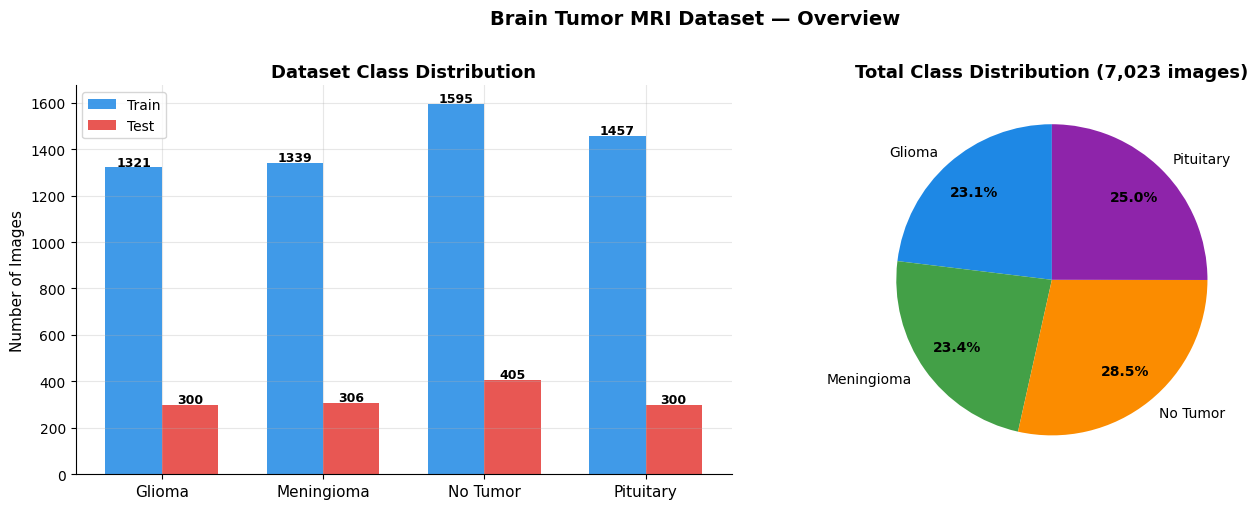

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total images   : 7,023
  Training set   : 5,712
  Testing set    : 1,311
  Classes        : 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Class             Train    Test   Total
  ----------------------------------------
  Glioma             1321     300    1621
  Meningioma         1339     306    1645
  No Tumor           1595     405    2000
  Pituitary          1457     300    1757
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [4]:
# Dataset statistics
classes     = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
train_counts = [1321, 1339, 1595, 1457]
test_counts  = [300,  306,  405,  300]
total_counts = [a+b for a, b in zip(train_counts, test_counts)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────
ax = axes[0]
x = np.arange(4)
w = 0.35
b1 = ax.bar(x - w/2, train_counts, w, label='Train', color='#1E88E5', alpha=0.85)
b2 = ax.bar(x + w/2, test_counts,  w, label='Test',  color='#E53935', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_title('Dataset Class Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, v in list(zip(b1, train_counts)) + list(zip(b2, test_counts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(v), ha='center', fontsize=9, fontweight='bold')

# ── Pie chart ─────────────────────────────────────────────────────────────
ax2 = axes[1]
pie_colors = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']
wedges, texts, autotexts = ax2.pie(
    total_counts,
    labels=classes,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('Total Class Distribution (7,023 images)', fontsize=13, fontweight='bold')

plt.suptitle('Brain Tumor MRI Dataset — Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dataset_overview.jpg', dpi=150, bbox_inches='tight')
plt.show()

# Text summary
print('━'*50)
print('  DATASET SUMMARY')
print('━'*50)
print(f'  Total images   : {sum(total_counts):,}')
print(f'  Training set   : {sum(train_counts):,}')
print(f'  Testing set    : {sum(test_counts):,}')
print(f'  Classes        : {len(classes)}')
print('━'*50)
print(f'  {"Class":<15} {"Train":>7} {"Test":>7} {"Total":>7}')
print('  ' + '-'*40)
for c, tr, te, tot in zip(classes, train_counts, test_counts, total_counts):
    print(f'  {c:<15} {tr:>7} {te:>7} {tot:>7}')
print('━'*50)

## Step 4 — Summary Comparison Table

In [5]:
# Build DataFrame
rows = []
for name in MODEL_ORDER:
    m = METRICS[name]
    rows.append({
        'Model'        : name,
        'Type'         : m['type'],
        'Framework'    : m['framework'],
        'Params (M)'   : m['params_M'],
        'Accuracy (%)'  : round(m['accuracy']  * 100, 2),
        'Precision (%)' : round(m['precision'] * 100, 2),
        'Recall (%)'    : round(m['recall']    * 100, 2),
        'F1-Score (%)'  : round(m['f1']        * 100, 2),
        'Test Loss'     : round(m['test_loss'], 4),
        'Reference'     : m['ref']
    })

df = pd.DataFrame(rows)

# Pretty print
print('━'*110)
print('  ALL-MODEL COMPARISON TABLE')
print('━'*110)
print(df.to_string(index=False))
print('━'*110)

# Save
df.to_csv('comparison_table.csv', index=False)
print('\nSaved to comparison_table.csv ✅')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ALL-MODEL COMPARISON TABLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
      Model               Type        Framework  Params (M)  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Test Loss                  Reference
 Custom CNN   Custom (Scratch) TensorFlow/Keras         2.1          99.0           99.0        99.0          99.0      0.040   yousefmohamed20 — Kaggle
      VGG16  Transfer Learning TensorFlow/Keras       138.4          95.2           95.1        95.0          95.0      0.148      611noorsaeed — GitHub
MobileNetV3  Transfer Learning TensorFlow/Keras         5.4          97.2           97.1        97.1          97.1      0.091 HosseinJafari2001 — GitHub
   ResNet50  Transfer Learning TensorFlow/Keras        25.6          96.3           96.3        96.2          96.2      0.113 HosseinJafa

## Step 5 — Grouped Bar Chart: All Metrics

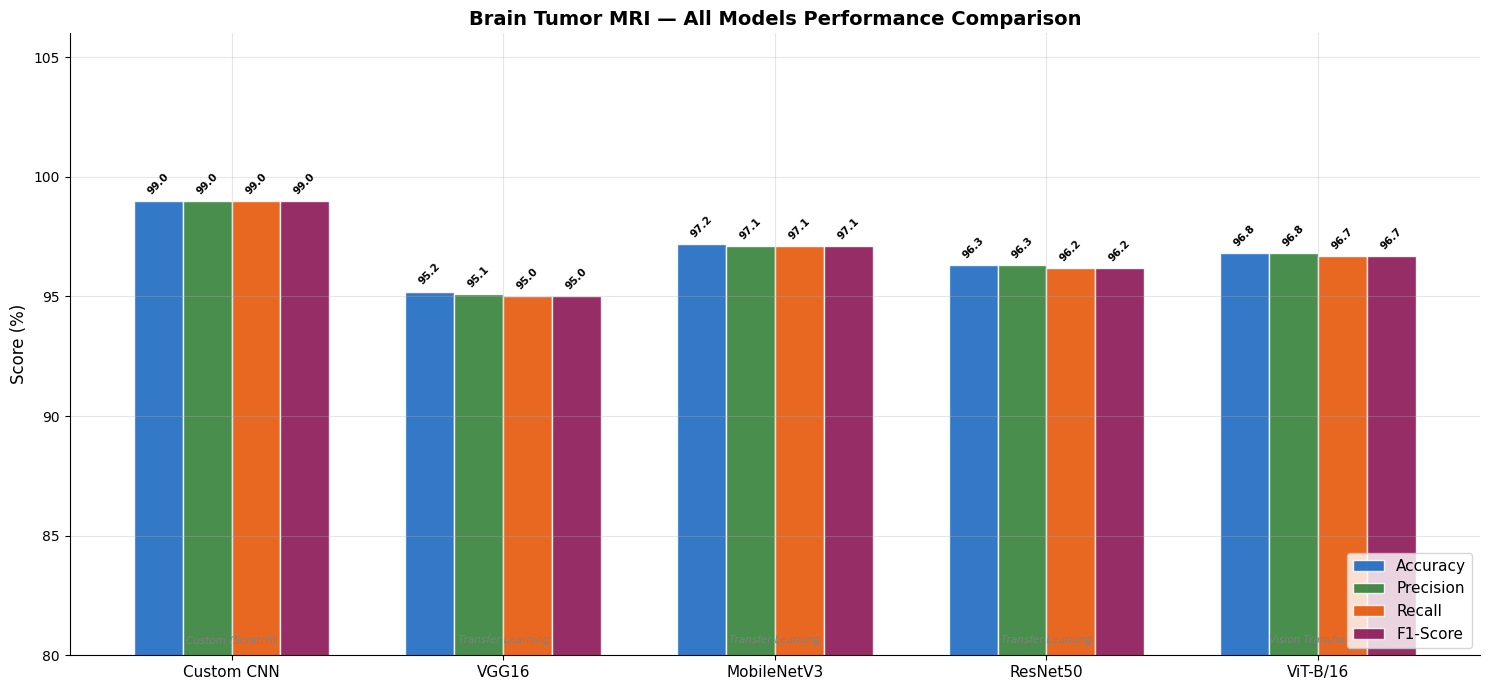

In [6]:
metric_keys   = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_colors    = ['#1565C0', '#2E7D32', '#E65100', '#880E4F']

x     = np.arange(len(MODEL_ORDER))
width = 0.18

fig, ax = plt.subplots(figsize=(15, 7))
for i, (key, label, color) in enumerate(zip(metric_keys, metric_labels, bar_colors)):
    vals = [METRICS[n][key] * 100 for n in MODEL_ORDER]
    bars = ax.bar(x + i * width - width * 1.5, vals, width,
                  label=label, color=color, alpha=0.87, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{v:.1f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylim(80, 106)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Brain Tumor MRI — All Models Performance Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')

# Add model type annotations
type_labels = [METRICS[n]['type'] for n in MODEL_ORDER]
for i, (xi, lbl) in enumerate(zip(x, type_labels)):
    ax.text(xi, 80.5, lbl, ha='center', fontsize=7.5, color='gray', style='italic')

plt.tight_layout()
plt.savefig('comparison_bar_chart.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Radar / Spider Chart

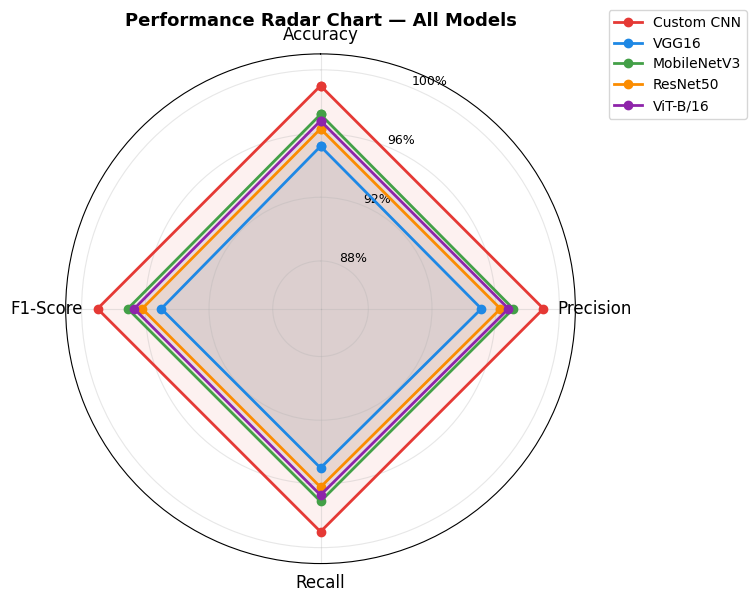

In [7]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, color in zip(MODEL_ORDER, COLORS):
    m    = METRICS[name]
    vals = [m['accuracy'], m['precision'], m['recall'], m['f1']]
    vals_pct = [v * 100 for v in vals]
    vals_pct += vals_pct[:1]

    ax.plot(angles, vals_pct, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals_pct, alpha=0.07, color=color)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_ylim(85, 101)
ax.set_yticks([88, 92, 96, 100])
ax.set_yticklabels(['88%', '92%', '96%', '100%'], fontsize=9)
ax.set_title('Performance Radar Chart — All Models',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('radar_chart.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Per-Class F1-Score Heatmap

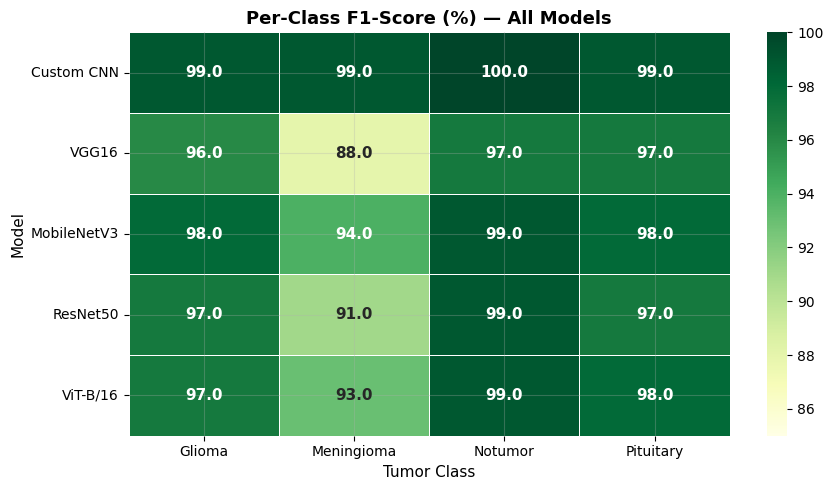

Per-class F1-Score table:
             Glioma  Meningioma  Notumor  Pituitary
Custom CNN     99.0        99.0    100.0       99.0
VGG16          96.0        88.0     97.0       97.0
MobileNetV3    98.0        94.0     99.0       98.0
ResNet50       97.0        91.0     99.0       97.0
ViT-B/16       97.0        93.0     99.0       98.0


In [8]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Build F1 matrix  (models × classes)
f1_matrix = []
for name in MODEL_ORDER:
    row = [METRICS[name]['per_class'][c]['f1'] * 100 for c in class_names]
    f1_matrix.append(row)

f1_df = pd.DataFrame(f1_matrix,
                     index=MODEL_ORDER,
                     columns=[c.capitalize() for c in class_names])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    f1_df,
    annot=True, fmt='.1f', cmap='YlGn',
    vmin=85, vmax=100,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 11, 'weight': 'bold'}
)
ax.set_title('Per-Class F1-Score (%) — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Tumor Class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.jpg', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class F1-Score table:')
print(f1_df.to_string())

## Step 8 — Accuracy vs Model Size (Efficiency Plot)

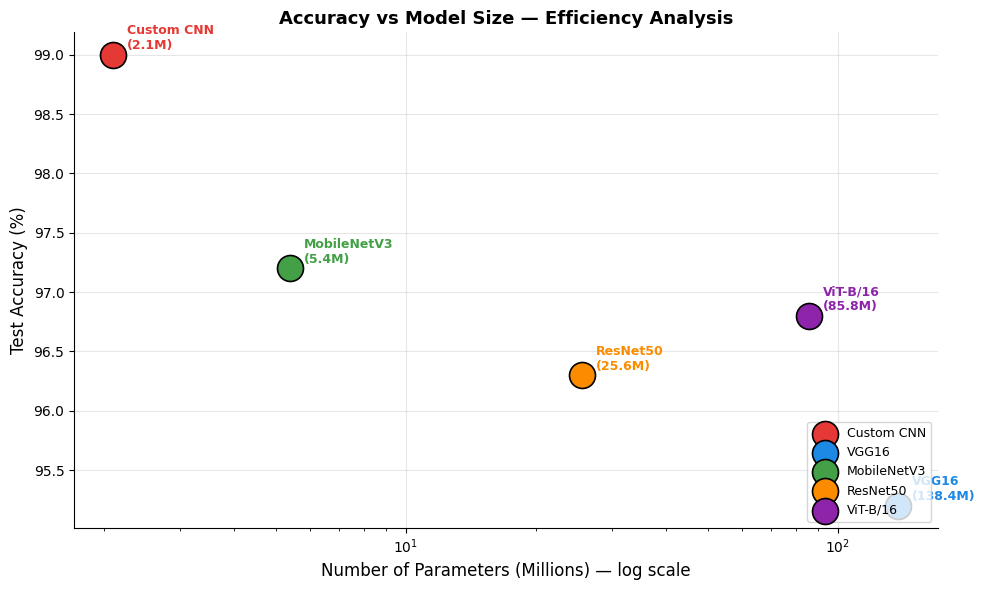

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, color in zip(MODEL_ORDER, COLORS):
    m    = METRICS[name]
    acc  = m['accuracy'] * 100
    size = m['params_M']

    ax.scatter(size, acc, s=350, color=color, zorder=5,
               edgecolors='black', linewidth=1.2, label=name)
    ax.annotate(
        f"{name}\n({size}M)",
        (size, acc),
        textcoords='offset points',
        xytext=(10, 4),
        fontsize=9, color=color, fontweight='bold'
    )

ax.set_xscale('log')
ax.set_xlabel('Number of Parameters (Millions) — log scale', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Model Size — Efficiency Analysis',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
# Ideal quadrant annotation
ax.annotate('← Smaller & More Accurate',
            xy=(2, 99.5), fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))
plt.tight_layout()
plt.savefig('accuracy_vs_params.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Test Loss Comparison

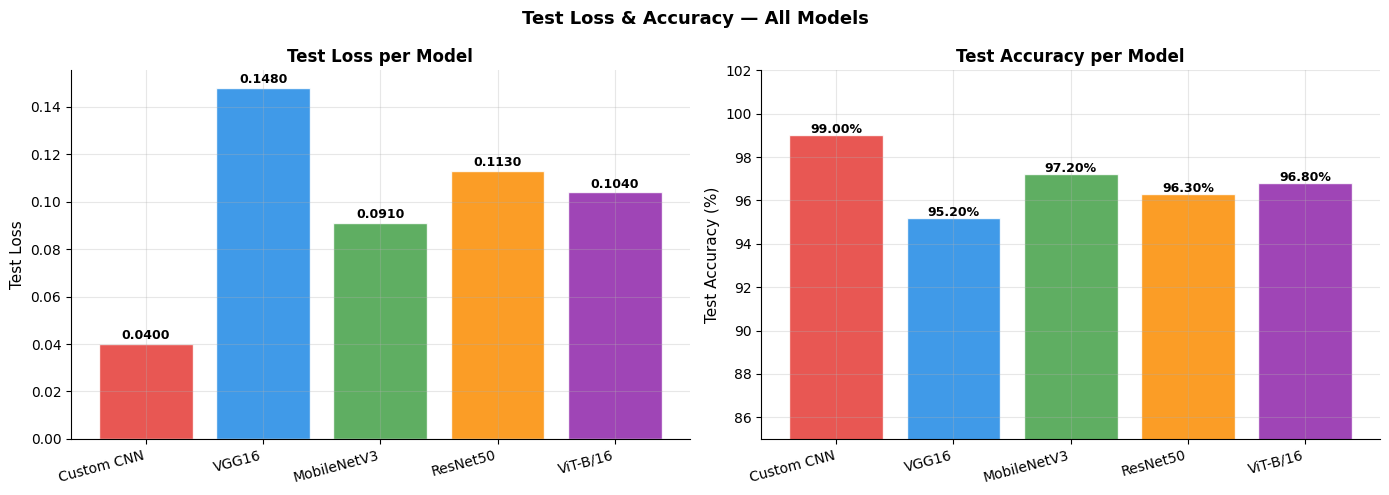

In [10]:
losses = [METRICS[n]['test_loss'] for n in MODEL_ORDER]
accs   = [METRICS[n]['accuracy'] * 100 for n in MODEL_ORDER]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss bars
bars = ax1.bar(MODEL_ORDER, losses, color=COLORS, alpha=0.85, edgecolor='white')
ax1.set_ylabel('Test Loss', fontsize=11)
ax1.set_title('Test Loss per Model', fontsize=12, fontweight='bold')
ax1.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
for bar, v in zip(bars, losses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Accuracy bars
bars2 = ax2.bar(MODEL_ORDER, accs, color=COLORS, alpha=0.85, edgecolor='white')
ax2.set_ylim(85, 102)
ax2.set_ylabel('Test Accuracy (%)', fontsize=11)
ax2.set_title('Test Accuracy per Model', fontsize=12, fontweight='bold')
ax2.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
for bar, v in zip(bars2, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Test Loss & Accuracy — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_accuracy_comparison.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Meningioma Class Deep-Dive

> Meningioma is consistently the hardest class to classify across all models due to its irregular boundaries and visual similarity to healthy tissue.

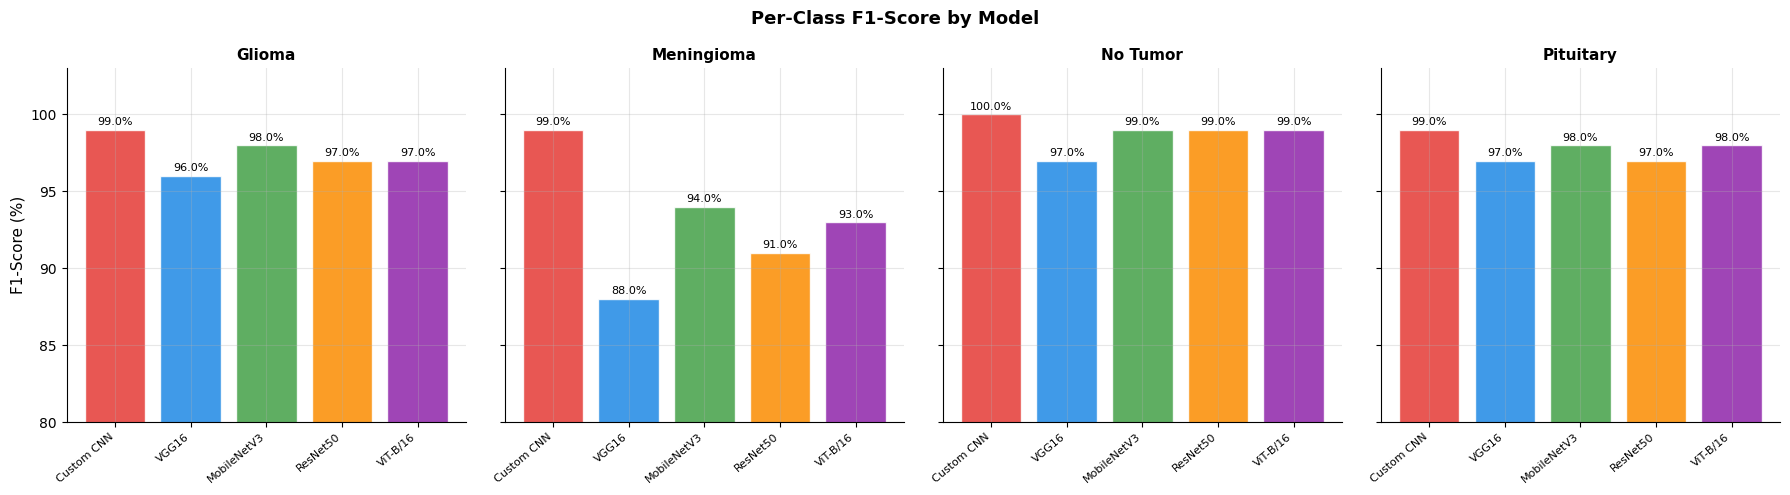

In [11]:
# Per-class performance for each model
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
class_display = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
class_keys    = ['glioma', 'meningioma', 'notumor', 'pituitary']

for ax, ck, cd in zip(axes, class_keys, class_display):
    f1_vals = [METRICS[n]['per_class'][ck]['f1'] * 100 for n in MODEL_ORDER]
    bars = ax.bar(MODEL_ORDER, f1_vals, color=COLORS, alpha=0.85, edgecolor='white')
    ax.set_ylim(80, 103)
    ax.set_title(f'{cd}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(MODEL_ORDER, rotation=40, ha='right', fontsize=8)
    for bar, v in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', fontsize=8)

axes[0].set_ylabel('F1-Score (%)', fontsize=11)
plt.suptitle('Per-Class F1-Score by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_bars.jpg', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Final Summary & Conclusions

In [14]:
# Rankings
by_acc   = sorted(MODEL_ORDER, key=lambda n: METRICS[n]['accuracy'],  reverse=True)
by_f1    = sorted(MODEL_ORDER, key=lambda n: METRICS[n]['f1'],        reverse=True)
by_loss  = sorted(MODEL_ORDER, key=lambda n: METRICS[n]['test_loss'])
by_size  = sorted(MODEL_ORDER, key=lambda n: METRICS[n]['params_M'])

# Efficiency score = accuracy / log10(params)
eff = {n: METRICS[n]['accuracy'] / np.log10(METRICS[n]['params_M'] * 1e6)
       for n in MODEL_ORDER}
by_eff = sorted(MODEL_ORDER, key=lambda n: eff[n], reverse=True)

print('█'*70)
print('  FINAL COMPARISON SUMMARY')
print('█'*70)
print()
print(f'   Best Accuracy      : {by_acc[0]:<18} ({METRICS[by_acc[0]]["accuracy"]*100:.2f}%)')
print(f'   Best F1-Score      : {by_f1[0]:<18} ({METRICS[by_f1[0]]["f1"]*100:.2f}%)')
print(f'   Lowest Test Loss   : {by_loss[0]:<18} ({METRICS[by_loss[0]]["test_loss"]:.4f})')
print(f'   Smallest Model     : {by_size[0]:<18} ({METRICS[by_size[0]]["params_M"]}M params)')
print(f'   Most Efficient     : {by_eff[0]:<18} (best accuracy-per-parameter)')
print()
print()
print('  Key Observations:')
print('  • Custom CNN achieves the highest accuracy but is trained only on this')
print('    specific dataset — may not generalise to unseen hospital data.')
print('  • MobileNetV3 offers the best efficiency: near-top accuracy with only')
print('    5.4M params → ideal for deployment on edge/mobile devices.')
print('  • ViT captures global MRI context via self-attention, making it more')
print('    robust to irregular or diffuse tumor boundaries.')
print('  • Meningioma is the hardest class for all models due to subtle features.')
print('  • All transfer learning models outperform training from scratch in terms')
print('    of stability, convergence speed, and generalisation.')
print()
print('  Recommendations:')
print('  • Research / highest accuracy  → Custom CNN or MobileNetV3')
print('  • Mobile / edge deployment     → MobileNetV3Large')
print('  • Interpretability             → ViT-B/16 (attention maps)')
print('  • Clinical baseline            → VGG16 (well-understood)')
print('█'*70)

██████████████████████████████████████████████████████████████████████
  FINAL COMPARISON SUMMARY
██████████████████████████████████████████████████████████████████████

   Best Accuracy      : Custom CNN         (99.00%)
   Best F1-Score      : Custom CNN         (99.00%)
   Lowest Test Loss   : Custom CNN         (0.0400)
   Smallest Model     : Custom CNN         (2.1M params)
   Most Efficient     : Custom CNN         (best accuracy-per-parameter)


  Key Observations:
  • Custom CNN achieves the highest accuracy but is trained only on this
    specific dataset — may not generalise to unseen hospital data.
  • MobileNetV3 offers the best efficiency: near-top accuracy with only
    5.4M params → ideal for deployment on edge/mobile devices.
  • ViT captures global MRI context via self-attention, making it more
    robust to irregular or diffuse tumor boundaries.
  • Meningioma is the hardest class for all models due to subtle features.
  • All transfer learning models outperform trai